# PDF to RDA DMP JSON - narrative plans

For traditional narrative plans - sections of prose, as in sample 3 - with their own prompt (v9). DMPTool-style plans such as sample 14 use `pdf-to-rda-dmp-json.ipynb`; a prompt change there does not reach this notebook.

One prompt: the text of a DMP PDF plus the complete **maDMP 1.2** schema, with
strict instructions to follow the schema — first with `llama3.1:8b`, then the same
prompt with `gemma4:e4b` and `llama3.3:70b`.

Every run of the notebook is saved in its own folder, `data/output/rda/runs/v1/`,
`v2/`, `v3/` ... — the result JSON per model, the exact prompt (`prompt.txt`) and the
timings (`run.json`). So you can change the prompt a little, run all cells again, and
nothing from an earlier run is lost. The run number is picked automatically. Set
`RUN_NAME` to a saved run (for example `"v1"`) to load its results and evaluate them
without calling the models again.

| Step | What happens |
|---|---|
| 1 | Read sample 14 with pdfplumber |
| 2 | Load the schema — unchanged |
| 3 | Prompt → `llama3.1:8b` |
| 4 | Same prompt → `gemma4:e4b` |
| 5 | Same prompt → `llama3.3:70b` |
| 6 | Save this run — results, prompt and timings under `runs/<RUN_NAME>/` |
| 7 | **Part 2 — Evaluate this run** against the hand-made reference: correct, hallucinated, missed; precision, recall, F1; charts |


In [1]:
import json
from pathlib import Path

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

from dmpbridge.extractors import get_extractor
from dmpbridge.models.ollama import OllamaModel

SAMPLES  = [3]
PDF_DIR  = Path("data/input/pdfs")
SCHEMA   = Path("data/output/rda/maDMP-schema-1.2.json")
HOST     = "http://localhost:11434"
NUM_CTX  = 32768
OPTIONS  = {"repeat_last_n": 1024}  # the repeat penalty looks back 1024 tokens, not Ollama's default 64:
                                    # with 64 or 512, llama3.1:8b repeated one dataset block until the token cap
MODEL_1  = "llama3.1:8b"
MODEL_2  = "gemma4:e4b"
MODEL_3  = "llama3.3:70b"
OUT_DIR  = Path("data/output/rda")

# Every run is saved in its own folder, data/output/rda/runs/<RUN_NAME>/, with its prompt.
#   RUN_NAME = None   -> a new run with the next number (v1, v2, v3 ...): the models are called
#   RUN_NAME = "v1"   -> that saved run is loaded and evaluated: the models are NOT called again
RUN_NAME = "v9-narrative"

import re
saved = sorted(p.name for p in (OUT_DIR / "runs").glob("*") if p.is_dir())
if RUN_NAME is None:
    numbers = [int(s[1:]) for s in saved if re.fullmatch(r"v\d+", s)]
    RUN_NAME = f"v{1 + max(numbers, default=0)}"
RUN_DIR = OUT_DIR / "runs" / RUN_NAME
if RUN_NAME in saved:
    print(f"this run: {RUN_NAME} - already saved, its results are loaded and the models are not called again")
else:
    print(f"this run: {RUN_NAME} - new")
print(f"saved runs: {', '.join(saved) or 'none'}")


this run: v9-narrative - already saved, its results are loaded and the models are not called again
saved runs: v1-sample14, v2-sample14, v3-sample14, v4a-sample14, v4b-sample14, v4c-sample14, v5-sample14, v9, v9-narrative


## Step 1 — Read the PDFs


In [2]:
dmp_texts = {}
for n in SAMPLES:
    dmp_texts[n] = get_extractor("pdfplumber").extract(PDF_DIR / f"sample{n}.pdf")[0]["text"]
    print(f"sample{n}: {len(dmp_texts[n]):,} characters")
    print(dmp_texts[n][:300])
    print()


sample3: 5,579 characters
** CPS 2015 **
** Roles and responsibilities **
** The Data Management Plan should clearly articulate how the PI and co-PIs plan to manage **
** and disseminate data generated by the project. The plan should outline the rights and **
** obligations of all parties as to their roles and responsibiliti



## Step 2 — Load the schema

The schema is used exactly as published — nothing removed, nothing changed.


In [3]:
schema = json.loads(SCHEMA.read_text(encoding="utf-8"))
defs = schema["$defs"]


def resolve_refs(node):
    """Replace every $ref with the definition it points at. Content unchanged."""
    if isinstance(node, dict):
        if "$ref" in node:
            return resolve_refs(defs[node["$ref"].split("/")[-1]])
        return {k: resolve_refs(v) for k, v in node.items() if k != "$defs"}
    if isinstance(node, list):
        return [resolve_refs(v) for v in node]
    return node


schema_full = resolve_refs(schema)
schema_text = json.dumps(schema_full, separators=(",", ":"))

print(f"{len(schema_text):,} characters of schema, {len(defs)} definitions resolved")


37,332 characters of schema, 48 definitions resolved


## Step 3 — Prompt → llama3.1:8b

The schema is given to the model twice: as text in the prompt, and as Ollama's
`format`, which constrains the JSON it generates to that structure. Without the
constraint, `llama3.1:8b` fell into a loop on this prompt and never stopped;
`num_predict` is a cap in case it ever does again.

Before each call the model is loaded and checked: if it does not sit **100% on
the GPU** it is skipped, because a model spilling onto the CPU turns minutes into
hours.


In [4]:
import subprocess
import time

import requests

SYSTEM = """You convert a Data Management Plan into one RDA maDMP JSON object that strictly follows the given schema.

Use only the schema's field names, in the places the schema puts them, with only its allowed values. The whole document is one top-level "dmp" object.

Capture everything the plan states, in the plan's own words. What each part of the RDA DMP Common Standard means:
- dmp: the plan itself. title: the plan's title or first heading, exactly as written. description: the plan's own statement of what it covers, if it has one.
- dataset: a logical group of data the plan describes, such as raw data, processed data, software or code, images, samples, protocols or publications - one entry for each group, whether it has its own heading or is only described in a sentence. Use the plan's own short phrase for the group as the title and the plan's sentences about it as the description. Data that the project only reuses, not produces, is a dataset with is_reused set to true. dataset_id: how the plan says the data will be identified, such as DOIs, with an empty identifier unless the plan gives one.
- distribution: one place where a dataset is kept or made available. A dataset can have several: for example the server where it is stored during the project, and the repository, archive, database or website where it is published at the end. Each named place is the host of its own distribution: the host title is the place's name as the plan writes it, and the host URL only if the plan gives one. data_access is open, shared or closed as the plan describes access. A license the plan names goes in that distribution's license, written as the plan writes it.
- metadata: the metadata standard the plan names, and in the description the plan's sentences about how the data will be documented or described.
- contributor: each person the plan names with a role, with that role.
- project: the project's title, its aims and scope as the description, and its funder.
A statement that clearly covers all of the data applies to every dataset; a statement about one group applies only to that one.

Template guidance is not part of the plan: ignore text that only explains what a plan should contain, such as a funder's questions or instructions.

Never invent a value. When the schema requires a field the plan does not give - a name, email, identifier, URL or a distribution's title - write an empty string, not a word such as "unknown", "N/A" or "not specified". The schema's examples are not data and must never appear in the output: not "Charlie Chaplin", "cc@example.com", "0000-0003-0644-4174", "10.1371/journal.pcbi.1006750", "11353/10.923628", "501100002428" or any example description. Never copy one item's identifier, title or description into another.

Output only the JSON. No explanation, no markdown."""


def make_prompt(dmp_text):
    return f"""Here is the RDA maDMP JSON schema (version 1.2). Follow it strictly:

{schema_text}

Here is the text of a Data Management Plan:

{dmp_text}

Generate one JSON object that strictly follows the schema above, filling in
whatever information the Data Management Plan text contains. Output only the JSON."""


def run(model, sample):
    """Send one sample's prompt to one model; the schema is also the output
    constraint. Prints the time taken and the tokens in and out. A result already
    saved in this run's folder is loaded instead, and the model is not called."""
    saved_result = RUN_DIR / f"sample{sample}.rda.{model.replace(':', '-')}.json"
    if saved_result.exists():
        print(f"{model}, sample{sample}: loaded from the saved run {RUN_NAME} - the model was not called")
        print()
        return json.loads(saved_result.read_text(encoding="utf-8"))
    if (RUN_DIR / f"sample{sample}.rda.{model.replace(':', '-')}.raw.txt").exists():
        print(f"{model}, sample{sample}: already failed in run {RUN_NAME} (no valid JSON) - not called again. "
              f"Delete the .raw.txt file in the run's folder to retry.")
        print()
        return None

    for other in (MODEL_1, MODEL_2, MODEL_3):
        if other != model:
            subprocess.run(["ollama", "stop", other], check=False)   # one model in VRAM at a time

    # Load the model, then make sure all of it is on the GPU before the real call.
    t0 = time.perf_counter()
    requests.post(f"{HOST}/api/generate", timeout=1800,
                  json={"model": model, "keep_alive": -1, "options": {"num_ctx": NUM_CTX}})
    load = time.perf_counter() - t0
    loaded = subprocess.run(["ollama", "ps"], capture_output=True, text=True).stdout
    placement = next((l for l in loaded.splitlines() if l.startswith(model)), "")
    if "100% GPU" not in placement:
        print(f"{model}, sample{sample}: SKIPPED - the model is not fully on the GPU")
        print(f"ollama ps says: {' '.join(placement.split()) or 'not loaded'}")
        print()
        subprocess.run(["ollama", "stop", model], check=False)
        return None

    llm = OllamaModel(model=model, host=HOST, num_ctx=NUM_CTX, num_predict=8000, options=OPTIONS)
    t0 = time.perf_counter()
    raw = llm.complete(SYSTEM, make_prompt(dmp_texts[sample]), schema=schema_full)
    elapsed = time.perf_counter() - t0

    s = llm.last_call
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        # The model never finished a valid JSON - usually it looped until the 8000-token cap.
        RUN_DIR.mkdir(parents=True, exist_ok=True)
        raw_file = RUN_DIR / f"sample{sample}.rda.{model.replace(':', '-')}.raw.txt"
        raw_file.write_text(raw, encoding="utf-8")
        print(f"{model}, sample{sample}: FAILED after {elapsed:.0f} s - no valid JSON "
              f"({s['eval_count']:,} tokens generated, stopped because: {s['done_reason']}). "
              f"What it wrote is in {raw_file.name}")
        print()
        return None
    timings[model, sample] = {"seconds": round(elapsed), "model_load_seconds": round(load),
                              "tokens_sent": s["prompt_eval_count"], "tokens_generated": s["eval_count"]}
    print(f"{model}, sample{sample}: {elapsed:.0f} s   (loading the model took {load:.0f} s)")
    print(f"tokens sent to the model: {s['prompt_eval_count']:,}   tokens generated: {s['eval_count']:,}")
    print()
    return result


def run_all(model):
    """One model over every sample; prints each result."""
    for n in SAMPLES:
        results[model, n] = run(model, n)
        if results[model, n] is None:
            for rest in SAMPLES:                 # skipped once: don't reload it per sample
                results.setdefault((model, rest), None)
            break
        print(json.dumps(results[model, n], indent=2, ensure_ascii=False))
        print()


results, timings = {}, {}
run_all(MODEL_1)


llama3.1:8b, sample3: loaded from the saved run v9-narrative - the model was not called

{
  "dmp": {
    "contact": {
      "contact_id": {
        "identifier": "",
        "type": ""
      },
      "mbox": "",
      "name": ""
    },
    "created": "2023-02-20T14:30:00Z",
    "dataset": [
      {
        "dataset_id": {
          "identifier": "",
          "type": ""
        },
        "personal_data": "no",
        "sensitive_data": "no",
        "title": "Data related to each of our proposed experiments",
        "type": "raw data"
      },
      {
        "dataset_id": {
          "identifier": "",
          "type": ""
        },
        "personal_data": "no",
        "sensitive_data": "no",
        "title": "Code and results for all analyses completed on experimental data",
        "type": "software"
      },
      {
        "dataset_id": {
          "identifier": "",
          "type": ""
        },
        "personal_data": "no",
        "sensitive_data": "no",
        "title":

## Step 4 — Same prompt → gemma4:e4b


In [5]:
run_all(MODEL_2)


gemma4:e4b, sample3: loaded from the saved run v9-narrative - the model was not called

{
  "dmp": {
    "contact": {
      "contact_id": {
        "identifier": "",
        "type": "unknown"
      },
      "mbox": "",
      "name": ""
    },
    "created": "2024-01-01T00:00:00Z",
    "dataset": [
      {
        "dataset_id": {
          "identifier": "",
          "type": "unknown"
        },
        "personal_data": "no",
        "sensitive_data": "no",
        "title": "data related to each of our proposed experiments",
        "description": "These will include the detailed protocols used for each experiment, the raw data collected from each experiment, and the experimental code used to collect those data. The relevant code will include both the data acquisition code, and the code for the controllers used in the experiment. Together, this information will be sufficient for recreating the circumstances of each data collection session."
      },
      {
        "dataset_id": {
     

## Step 5 — Same prompt → llama3.3:70b

The 70B needs about 53 GB of VRAM at this context size — all three 24 GB cards.
With fewer cards available it cannot sit fully on the GPU and is skipped.


In [6]:
run_all(MODEL_3)


llama3.3:70b, sample3: loaded from the saved run v9-narrative - the model was not called

{
  "dmp": {
    "contact": {
      "contact_id": {
        "identifier": "",
        "type": ""
      },
      "mbox": "",
      "name": ""
    },
    "created": "2020-01-01T00:00:00Z",
    "dataset": [
      {
        "dataset_id": {
          "identifier": "",
          "type": ""
        },
        "personal_data": "no",
        "sensitive_data": "no",
        "title": "Experimental data",
        "description": "Data related to each of our proposed experiments. These will include the detailed protocols used for each experiment, the raw data collected from each experiment, and the experimental code used to collect those data."
      },
      {
        "dataset_id": {
          "identifier": "",
          "type": ""
        },
        "personal_data": "no",
        "sensitive_data": "no",
        "title": "Analysis code and results",
        "description": "The code and results for all analyses

## Step 6 — Save this run

Everything goes into `data/output/rda/runs/<RUN_NAME>/`: the result JSON per model,
`prompt.txt` (the exact prompt that produced them) and `run.json` (timings and tokens).

Part 2 below evaluates exactly these files.


In [7]:
from datetime import datetime

RUN_DIR.mkdir(parents=True, exist_ok=True)
for (model, n), result in results.items():
    if result is None:
        print(f"{model:14} sample{n}: skipped, nothing saved")
        continue
    name = f"sample{n}.rda.{model.replace(':', '-')}.json"
    (RUN_DIR / name).write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"{model:14} sample{n} -> {RUN_DIR / name}")

# The exact prompt and settings behind these results, so the run can be reproduced.
# For a loaded run the prompt on record is the one that produced the results, so it is kept.
prompt_now = ("SYSTEM:\n" + SYSTEM + "\n\nPROMPT (the schema and the document text go in the braces):\n"
              + make_prompt("{dmp_text}").replace(schema_text, "{schema_text}"))
prompt_file = RUN_DIR / "prompt.txt"
if not prompt_file.exists():
    prompt_file.write_text(prompt_now, encoding="utf-8")
elif prompt_file.read_text(encoding="utf-8") != prompt_now:
    print(f"\nNOTE: the prompt in this notebook is not the one saved for {RUN_NAME}; the loaded results "
          f"came from the saved one (prompt.txt). For a new prompt set RUN_NAME = None.")

run_file = RUN_DIR / "run.json"
earlier = json.loads(run_file.read_text(encoding="utf-8")) if run_file.exists() else {}
run_file.write_text(json.dumps({
    "run": RUN_NAME, "date": earlier.get("date", datetime.now().isoformat(timespec="minutes")),
    "samples": SAMPLES, "models": [MODEL_1, MODEL_2, MODEL_3], "schema": SCHEMA.name, "num_ctx": NUM_CTX,
    "options": OPTIONS,
    "timings": {**earlier.get("timings", {}), **{f"{m} sample{n}": t for (m, n), t in timings.items()}},
    "skipped": [f"{m} sample{n}" for (m, n), r in results.items() if r is None],
}, indent=2), encoding="utf-8")
print(f"\nprompt.txt and run.json -> {RUN_DIR}")


llama3.1:8b    sample3 -> data\output\rda\runs\v9-narrative\sample3.rda.llama3.1-8b.json
gemma4:e4b     sample3 -> data\output\rda\runs\v9-narrative\sample3.rda.gemma4-e4b.json
llama3.3:70b   sample3 -> data\output\rda\runs\v9-narrative\sample3.rda.llama3.3-70b.json

prompt.txt and run.json -> data\output\rda\runs\v9-narrative


# Part 2 — How well did the models fill in the RDA DMP form?

The three results saved above are compared with the same form filled in by hand, carefully,
from the same PDF (`RDA_DMP_sample14_manual_annotation.json`). The scores and charts are
saved in this run's folder, so every prompt version keeps its own evaluation.

**Not technical? Read this cell, then sections 5, 7 and 8, and "In plain words" at the end.**
Sections 1–4 show the mechanics of how the comparison is made.

**Every field the model wrote gets one of three marks**

| Mark | Meaning |
|---|---|
| **Correct** | the model's value matches what the person wrote — or both left it blank |
| **Hallucinated** | the model wrote something wrong, made up something that is not in the document, or left blank a field the person filled in |
| **Missed** | the person filled it in; the model never got it |

Every field the model wrote is either Correct or Hallucinated, so those two add up to
"fields the model output". Missed is counted on the person's side.

**Three scores sum each model up**

- **precision** — of everything the model wrote, the share that was right
- **recall** — of everything the document contains, the share the model found
- **F1** — one number that balances the two (section 5 shows the arithmetic)

**When do two values count as "the same"?** Strictly for identifiers — a DOI, an email, a
URL must be the same thing, ignoring `https://` and capital letters. Leniently for text: a
title or description counts as right when at least three-quarters of the model's words appear
in the person's version, so a shortened title passes but a title with extra words added does
not. Dates count as the same if they are the same day, however they are written, and a
licence can be given as a name or as its web address.


In [8]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    import os
    os.chdir(Path.cwd().parent)

# The project's own containment rule, so this evaluation and Path A / B agree.
from dmpbridge.evaluation.evaluate import tokenize, containment, CONTAINMENT_THRESHOLD

# ── Where things are ─────────────────────────────────────────────────────────
RDA_DIR   = Path("data/output/rda")
MODELS    = [m.replace(":", "-") for m in (MODEL_1, MODEL_2, MODEL_3)]   # as in the file names
REFERENCE = "RDA_DMP_sample{n}_manual_annotation.json"           # one per sample, in RDA_DIR
OUTPUT    = "sample{n}.rda.{model}.json"                         # one per sample and model, in RUN_DIR
RESULTS   = RUN_DIR / "evaluation_results.xlsx"
CHART     = RUN_DIR / "evaluation_charts.png"

# ── Judging rules ────────────────────────────────────────────────────────────
EMPTY       = {"", "null", "none", "n/a", "na"}                     # what counts as "nothing"
THRESHOLD   = CONTAINMENT_THRESHOLD                                 # 0.75: share of the model's words that must be in the reference
ONE_OR_MANY = {"contact_id", "contributor_id", "creator_id", "metadata_standard_id"}  # schema allows one object or a list

ID_FIELDS   = {"identifier", "mbox", "url", "access_url", "download_url", "scheme_uri", "license_ref"}
DATE_FIELDS = {"created", "modified", "issued", "start", "end", "start_date", "available_until"}
ENUM_FIELDS = {"type", "data_access", "personal_data", "sensitive_data", "ethical_issues_exist",
               "language", "relation_type", "resource_type", "funding_status", "role",
               "certified_with", "geo_location", "pid_system", "currency_code", "is_reused"}

# ── Chart style: the repo's palette ──────────────────────────────────────────
# Verdicts: a validated blue/red pair plus a neutral gray for "missed" (deliberately
# colourless — it means nothing was extracted). Models: the same slot order every
# other notebook in this repo uses, so a model's colour never changes.
VERDICT_COLOUR = {"Correct": "#2a78d6", "Hallucinated": "#e34948", "Missed": "#898781"}
MODEL_COLOUR   = dict(zip(MODELS, ["#2a78d6", "#eb6834", "#1baf7a"]))
INK, MUTED, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e6e6e2"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d8d8d4", "axes.titlecolor": INK,
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.grid": False, "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 200)

samples = [n for n in SAMPLES if (RDA_DIR / REFERENCE.format(n=n)).exists()]
print(f"evaluating run {RUN_NAME} in {RUN_DIR}")
print("samples with a reference:", samples)
if not samples:
    print(f"\nNo hand-made reference for sample {SAMPLES} (expected {RDA_DIR / REFERENCE.format(n=SAMPLES[0])}).")
    print("The models' JSON files are saved above; the scoring cells below are skipped.")
for n in samples:
    have = [m for m in MODELS if (RUN_DIR / OUTPUT.format(n=n, model=m)).exists()]
    print(f"  sample{n}: outputs from {', '.join(have) or 'NO MODEL - nothing to evaluate here'}")


evaluating run v9-narrative in data\output\rda\runs\v9-narrative
samples with a reference: [3]
  sample3: outputs from llama3.1-8b, gemma4-e4b, llama3.3-70b


## 1. Turn each JSON file into a list of fields

The form is nested — datasets inside the plan, licences inside datasets. To compare two
forms, every entry becomes one line: the field's name and its value. Fields the person
left blank are not part of the reference; a field the model wrote but left blank still
counts as something the model wrote.


In [9]:
if not samples:
    print("skipped - no reference for this sample")
else:
    def is_empty(v):
        return v is None or v == [] or v == {} or (isinstance(v, str) and v.strip().lower() in EMPTY)


    def canonical(node):
        """Wrap a single object into a one-item list wherever the schema allows either."""
        if isinstance(node, dict):
            out = {}
            for k, v in node.items():
                v = canonical(v)
                if k in ONE_OR_MANY and isinstance(v, dict):
                    v = [v]
                out[k] = v
            return out
        if isinstance(node, list):
            return [canonical(v) for v in node]
        return node


    def flatten(node, path=""):
        """Every leaf of a document as (path, value)."""
        if isinstance(node, dict):
            for k, v in node.items():
                yield from flatten(v, f"{path}.{k}" if path else k)
        elif isinstance(node, list):
            for i, v in enumerate(node):
                yield from flatten(v, f"{path}[{i}]")
        else:
            yield path, node


    def load(path):
        return canonical(json.loads(Path(path).read_text(encoding="utf-8")))


    ref = load(RDA_DIR / REFERENCE.format(n=samples[0]))
    ref_fields = {p: v for p, v in flatten(ref) if not is_empty(v)}
    print(f"sample{samples[0]} reference: {len(ref_fields)} fields with a value")
    for p, v in list(ref_fields.items())[:6]:
        print(f"  {p:48} {json.dumps(v, ensure_ascii=False)[:60]}")
    print("  ...")


sample3 reference: 26 fields with a value
  dmp.title                                        "CPS 2015"
  dmp.description                                  "We will manage all scientific and technical content generat
  dmp.dataset[0].title                             "data related to each of our proposed experiments"
  dmp.dataset[0].description                       "First, we will have data related to each of our proposed ex
  dmp.dataset[0].personal_data                     "no"
  dmp.dataset[0].sensitive_data                    "no"
  ...


## 2. Match up the datasets

A model may list the datasets in a different order from the person, or find only some of
them. Each dataset (or contributor) the model wrote is paired with the person's entry that
has the same title or name; where there is no such match, with the entry in the same
position. The print-out shows which was paired with which.


In [10]:
if not samples:
    print("skipped - no reference for this sample")
else:
    KEY_FIELDS = ("title", "name", "identifier", "license_ref")


    def norm_text(v):
        return re.sub(r"\s+", " ", str(v)).strip().lower()


    def item_key(item):
        """The value that identifies a list item, if it has one."""
        if isinstance(item, dict):
            for k in KEY_FIELDS:
                if not is_empty(item.get(k)):
                    return norm_text(item[k])
            return None
        return norm_text(item) if not is_empty(item) else None


    def pair_items(model_list, ref_list):
        """model index -> reference index. Exact key matches first, then position."""
        ref_keys = {item_key(r): j for j, r in enumerate(ref_list)}
        ref_keys.pop(None, None)
        mapping, taken = {}, set()
        for i, m in enumerate(model_list):                       # pass 1: same title / name
            j = ref_keys.get(item_key(m))
            if j is not None and j not in taken:
                mapping[i], taken = j, taken | {j}
        for i, m in enumerate(model_list):                       # pass 2: same position, else a free slot
            if i in mapping:
                continue
            j = i if i not in taken else next((k for k in range(len(ref_list)) if k not in taken), None)
            if j is None:                                        # more items than the reference has
                j = len(ref_list) + len([x for x in mapping.values() if x >= len(ref_list)])
            mapping[i], taken = j, taken | {j}
        return mapping


    def flatten_aligned(model, ref, path="", mpath=""):
        """Flatten the model document using the reference's list indices.
        Yields (reference-aligned path, the model's own path, value)."""
        if isinstance(model, dict):
            for k, v in model.items():
                r = ref.get(k) if isinstance(ref, dict) else None
                yield from flatten_aligned(v, r, f"{path}.{k}" if path else k, f"{mpath}.{k}" if mpath else k)
        elif isinstance(model, list):
            ref_list = ref if isinstance(ref, list) else []
            mapping = pair_items(model, ref_list)
            for i, v in enumerate(model):
                j = mapping[i]
                yield from flatten_aligned(v, ref_list[j] if j < len(ref_list) else None,
                                           f"{path}[{j}]", f"{mpath}[{i}]")
        else:
            yield path, mpath, model


    # How each model's datasets were paired, for the first sample
    ds_ref = ref.get("dmp", {}).get("dataset", [])
    for m in MODELS:
        p = RUN_DIR / OUTPUT.format(n=samples[0], model=m)
        if not p.exists():
            continue
        ds_model = load(p).get("dmp", {}).get("dataset", [])
        print(f"{m}:")
        for i, j in pair_items(ds_model, ds_ref).items():
            mt = ds_model[i].get("title") if isinstance(ds_model[i], dict) else ds_model[i]
            rt = ds_ref[j].get("title") if j < len(ds_ref) else "(no reference item)"
            print(f"   model dataset[{i}] {str(mt)[:36]!r:40} -> reference dataset[{j}] {str(rt)[:36]!r}")


llama3.1-8b:
   model dataset[0] 'Data related to each of our proposed'   -> reference dataset[0] 'data related to each of our proposed'
   model dataset[1] 'Code and results for all analyses co'   -> reference dataset[1] 'code and results for all analyses co'
   model dataset[2] 'Simulation code for controller devel'   -> reference dataset[2] 'simulation code for controller devel'
gemma4-e4b:
   model dataset[0] 'data related to each of our proposed'   -> reference dataset[0] 'data related to each of our proposed'
   model dataset[1] 'code and results for all analyses co'   -> reference dataset[1] 'code and results for all analyses co'
   model dataset[2] 'Software generated under the project'   -> reference dataset[2] 'simulation code for controller devel'
llama3.3-70b:
   model dataset[0] 'Experimental data'                      -> reference dataset[0] 'data related to each of our proposed'
   model dataset[1] 'Analysis code and results'              -> reference dataset[1] 'code an

## 3. Decide whether each value is right

One function applies the rules described at the top. The examples underneath are real
cases from sample 14 and show how the rules decide.


In [11]:
if not samples:
    print("skipped - no reference for this sample")
else:
    def field_kind(path):
        last = re.sub(r"\[\d+\]$", "", path.split(".")[-1])
        if last in ID_FIELDS:   return "identifier"
        if last in DATE_FIELDS: return "date"
        if last in ENUM_FIELDS: return "controlled"
        return "text"


    LICENCE = [(re.compile(r"creativecommons\.org/licenses/([a-z\-]+)/(\d\.\d)"), r"cc-\1-\2"),
               (re.compile(r"^cc[\s\-]+([a-z][a-z\-]*)[\s\-]+(\d\.\d)$"), r"cc-\1-\2")]


    def norm_id(v):
        s = norm_text(v)
        s = re.sub(r"^https?://", "", s)
        s = re.sub(r"^(www\.|dx\.)?doi\.org/", "", s)
        s = re.sub(r"^www\.", "", s).rstrip("/")
        for pattern, repl in LICENCE:
            if pattern.search(s):
                return pattern.sub(repl, s)
        return s


    def norm_date(v):
        m = re.search(r"(\d{4})-(\d{2})-(\d{2})", norm_text(v))
        return f"{m[1]}-{m[2]}-{m[3]}" if m else norm_text(v)


    def verdict(path, mv, rv):
        """-> (verdict, reason)."""
        m_empty, r_empty = is_empty(mv), is_empty(rv)
        if m_empty and r_empty:
            return "Correct", "both empty"
        if m_empty:
            return "Hallucinated", "empty where the reference has a value"
        if r_empty:
            return "Hallucinated", "not in the reference"
        kind = field_kind(path)
        if kind == "identifier":
            ok, how = norm_id(mv) == norm_id(rv), "identifier differs"
        elif kind == "date":
            ok, how = norm_date(mv) == norm_date(rv), "different day"
        elif kind == "controlled":
            ok, how = norm_text(mv) == norm_text(rv), "different value"
        else:
            share = containment(tokenize(str(mv)), tokenize(str(rv)))
            ok, how = share >= THRESHOLD, f"only {share:.0%} of the model's words are in the reference"
        return ("Correct", "") if ok else ("Hallucinated", how)


    examples = [
        ("dmp.dataset[0].title", "Hakai JSP Time Series", "Hakai Institute Juvenile Salmon Program Time Series"),
        ("dmp.title", "Hakai Institute Juvenile Salmon Program Time Series Data Management Plan",
                      "Hakai Institute Juvenile Salmon Program Time Series"),
        ("dmp.dataset[0].distribution[0].license[0].license_ref", "https://creativecommons.org/licenses/by/4.0/", "CC BY 4.0"),
        ("dmp.project[0].start", "2015-05-12T00:00:00Z", "2015-05-12"),
        ("dmp.contact.mbox", "brett.johnson@hakai.org", None),
        ("dmp.contact.mbox", "N/A", None),
        ("dmp.contact.name", "N/A", "Brett Johnson"),
        ("dmp.dataset[0].dataset_id.identifier", "https://doi.org/10.48321/D1CW23", "https://doi.org/10.21966/1.566666"),
    ]
    print(f"{'verdict':13} {'model value':46} {'reference value':38} reason")
    for path, mv, rv in examples:
        v, why = verdict(path, mv, rv)
        print(f"{v:13} {str(mv)[:42]!r:46} {str(rv)[:34]!r:38} {why}")


verdict       model value                                    reference value                        reason
Correct       'Hakai JSP Time Series'                        'Hakai Institute Juvenile Salmon Pr'   
Hallucinated  'Hakai Institute Juvenile Salmon Program Ti'   'Hakai Institute Juvenile Salmon Pr'   only 70% of the model's words are in the reference
Correct       'https://creativecommons.org/licenses/by/4.'   'CC BY 4.0'                            
Correct       '2015-05-12T00:00:00Z'                         '2015-05-12'                           
Hallucinated  'brett.johnson@hakai.org'                      'None'                                 not in the reference
Correct       'N/A'                                          'None'                                 both empty
Hallucinated  'N/A'                                          'Brett Johnson'                        empty where the reference has a value
Hallucinated  'https://doi.org/10.48321/D1CW23'              'https:/

## 4. Score everything

One line per field, for every model. The table counts the marks.


In [12]:
if not samples:
    print("skipped - no reference for this sample")
else:
    rows = []
    for n in samples:
        ref = load(RDA_DIR / REFERENCE.format(n=n))
        ref_values = dict(flatten(ref))
        ref_fields = {p for p, v in ref_values.items() if not is_empty(v)}
        for m in MODELS:
            p = RUN_DIR / OUTPUT.format(n=n, model=m)
            if not p.exists():
                continue
            covered = set()
            for path, mpath, mv in flatten_aligned(load(p), ref):
                rv = ref_values.get(path)
                v, why = verdict(path, mv, rv)
                if v == "Correct" and path in ref_fields:
                    covered.add(path)
                rows.append({"sample": n, "model": m, "field": path, "model field": mpath, "model value": mv,
                             "reference value": rv, "verdict": v, "reason": why})
            for path in sorted(ref_fields - covered):
                rows.append({"sample": n, "model": m, "field": path, "model field": None, "model value": None,
                             "reference value": ref_values[path], "verdict": "Missed", "reason": ""})

    details = pd.DataFrame(rows)
    if details.empty:
        raise SystemExit(f"No model outputs to evaluate in {OUT_DIR} - looking for files named like "
                         f"{OUTPUT.format(n=samples[0] if samples else 'N', model='<model>')}. "
                         "Run Part 1 first, or check RUN_NAME.")
    print(f"{len(details)} judged rows across {len(samples)} sample(s) and {details['model'].nunique()} models\n")
    details.groupby(["model", "verdict"]).size().unstack(fill_value=0)[["Correct", "Hallucinated", "Missed"]].loc[
        [m for m in MODELS if m in set(details["model"])]]


150 judged rows across 1 sample(s) and 3 models



## 5. The scores

One row per model. *Fields in reference* is how many fields the person filled in;
*fields output* is how many the model wrote. The worked example underneath shows the
arithmetic with the real numbers.


In [13]:
if not samples:
    print("skipped - no reference for this sample")
else:
    def metrics(df, n_ref):
        c = int((df["verdict"] == "Correct").sum())
        h = int((df["verdict"] == "Hallucinated").sum())
        miss = int((df["verdict"] == "Missed").sum())
        out, found, total = c + h, n_ref - miss, c + h + miss
        precision = c / out if out else 0.0
        recall = found / n_ref if n_ref else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        return {"fields in reference": n_ref, "fields output": out, "correct": c, "hallucinated": h,
                "missed": miss, "precision": round(precision, 3), "recall": round(recall, 3), "f1": round(f1, 3),
                "correct %": c / total, "hallucinated %": h / total, "missed %": miss / total}


    n_ref = {n: len({p for p, v in flatten(load(RDA_DIR / REFERENCE.format(n=n))) if not is_empty(v)}) for n in samples}
    summary = pd.DataFrame([{"model": m, **metrics(details[details["model"] == m], sum(n_ref.values()))}
                            for m in MODELS if m in set(details["model"])]).set_index("model")

    def show(df):
        """The metrics table with the shares as percentages."""
        out = df.copy()
        for c in ("correct %", "hallucinated %", "missed %"):
            out[c] = out[c].map("{:.1%}".format)
        display(out)


    show(summary)

    if len(samples) > 1:
        per_sample = pd.DataFrame([{"sample": n, "model": m, **metrics(details[(details["model"] == m) & (details["sample"] == n)], n_ref[n])}
                                   for n in samples for m in MODELS if ((details["model"] == m) & (details["sample"] == n)).any()]
                                  ).set_index(["sample", "model"])
        print("\nPer sample:")
        show(per_sample)

    # The arithmetic behind the three numbers, with this run's values for the first model
    m = summary.index[0]
    c, out, ref_n, miss = (int(summary.loc[m, k]) for k in ("correct", "fields output", "fields in reference", "missed"))
    print(f"\nWorked example, {m}:")
    print(f"  precision = correct / fields output              = {c} / {out} = {summary.loc[m, 'precision']}")
    print(f"  recall    = (reference - missed) / reference     = ({ref_n} - {miss}) / {ref_n} = {summary.loc[m, 'recall']}")
    print(f"  F1        = 2 * precision * recall / (precision + recall) = {summary.loc[m, 'f1']}")


,fields in reference,fields output,correct,hallucinated,missed,precision,recall,f1,correct %,hallucinated %,missed %
model,,,,,,,,,,,
llama3.1-8b,26,34,24,10,16,0.706,0.385,0.498,48.0%,20.0%,32.0%
gemma4-e4b,26,32,20,12,16,0.625,0.385,0.476,41.7%,25.0%,33.3%
llama3.3-70b,26,38,29,9,14,0.763,0.462,0.575,55.8%,17.3%,26.9%



Worked example, llama3.1-8b:
  precision = correct / fields output              = 24 / 34 = 0.706
  recall    = (reference - missed) / reference     = (26 - 16) / 26 = 0.385
  F1        = 2 * precision * recall / (precision + recall) = 0.498


## 6. Every field, model by model

What each model wrote, next to what the person wrote, with the mark and the reason.
Hallucinated rows come first so the problems are at the top.


In [14]:
if not samples:
    print("skipped - no reference for this sample")
else:
    ORDER = {"Hallucinated": 0, "Correct": 1}
    for m in MODELS:
        d = details[(details["model"] == m) & (details["verdict"] != "Missed")].copy()
        if d.empty:
            continue
        d = d.sort_values(["sample", "verdict", "model field"], key=lambda col: col.map(ORDER) if col.name == "verdict" else col)
        counts = details[details["model"] == m]["verdict"].value_counts()
        print(f"\n{'=' * 100}\n{m}: {counts.get('Correct', 0)} correct, {counts.get('Hallucinated', 0)} hallucinated, "
              f"{counts.get('Missed', 0)} missed\n{'=' * 100}")
        display(d[["sample", "model field", "model value", "reference value", "verdict", "reason"]]
                .rename(columns={"model field": "field"}).reset_index(drop=True))



llama3.1-8b: 24 correct, 10 hallucinated, 16 missed


,sample,field,model value,reference value,verdict,reason
0,3,dmp.created,2023-02-20T14:30:00Z,None,Hallucinated,not in the reference
1,3,dmp.dataset[0].type,raw data,None,Hallucinated,not in the reference
2,3,dmp.dataset[1].type,software,None,Hallucinated,not in the reference
3,3,dmp.dataset[2].type,software,None,Hallucinated,not in the reference
4,3,dmp.ethical_issues_exist,no,None,Hallucinated,not in the reference
5,3,dmp.language,eng,None,Hallucinated,not in the reference
6,3,dmp.modified,2023-02-20T14:30:00Z,None,Hallucinated,not in the reference
7,3,dmp.project[0].description,This project aims to analyze the impact of urbanization on local b...,None,Hallucinated,not in the reference
8,3,dmp.project[0].funding[0].funding_status,granted,None,Hallucinated,not in the reference
9,3,dmp.project[0].title,CPS 2015,None,Hallucinated,not in the reference



gemma4-e4b: 20 correct, 12 hallucinated, 16 missed


,sample,field,model value,reference value,verdict,reason
0,3,dmp.contact.contact_id[0].type,unknown,None,Hallucinated,not in the reference
1,3,dmp.created,2024-01-01T00:00:00Z,None,Hallucinated,not in the reference
2,3,dmp.dataset[0].dataset_id.type,unknown,None,Hallucinated,not in the reference
3,3,dmp.dataset[1].dataset_id.type,unknown,None,Hallucinated,not in the reference
4,3,dmp.dataset[1].description,"We store all code necessary to recreate figures, tables, and other...",Our second type of data will be the code and results for all analy...,Hallucinated,only 56% of the model's words are in the reference
5,3,dmp.dataset[2].dataset_id.type,unknown,None,Hallucinated,not in the reference
6,3,dmp.dataset[2].description,Software generated under the project will be released under the GN...,The proposed foundational developments will produce substantial si...,Hallucinated,only 21% of the model's words are in the reference
7,3,dmp.dataset[2].title,Software generated under the project,simulation code for controller development and testing,Hallucinated,only 0% of the model's words are in the reference
8,3,dmp.dmp_id.type,unknown,None,Hallucinated,not in the reference
9,3,dmp.ethical_issues_exist,no,None,Hallucinated,not in the reference



llama3.3-70b: 29 correct, 9 hallucinated, 14 missed


,sample,field,model value,reference value,verdict,reason
0,3,dmp.created,2020-01-01T00:00:00Z,None,Hallucinated,not in the reference
1,3,dmp.dataset[0].title,Experimental data,data related to each of our proposed experiments,Hallucinated,only 50% of the model's words are in the reference
2,3,dmp.description,Data Management Plan for CPS 2015 project,We will manage all scientific and technical content generated from...,Hallucinated,only 14% of the model's words are in the reference
3,3,dmp.ethical_issues_exist,no,None,Hallucinated,not in the reference
4,3,dmp.language,eng,None,Hallucinated,not in the reference
5,3,dmp.modified,2020-01-01T00:00:00Z,None,Hallucinated,not in the reference
6,3,dmp.project[0].description,This project aims to analyze the impact of urbanization on local b...,None,Hallucinated,not in the reference
7,3,dmp.project[0].funding[0].funding_status,planned,None,Hallucinated,not in the reference
8,3,dmp.project[0].title,CPS 2015,None,Hallucinated,not in the reference
9,3,dmp.contact.contact_id[0].identifier,,None,Correct,both empty


## 7. What the models miss

The missed fields grouped by the part of the form they belong to, next to how many
fields that part has. This shows what *kind* of information gets lost, which the overall
count hides.


In [15]:
if not samples:
    print("skipped - no reference for this sample")
else:
    def section(path):
        parts = path.split(".")
        return re.sub(r"\[\d+\]", "", parts[1]) if parts[0] == "dmp" and len(parts) > 1 else parts[0]


    ref_counts = pd.Series([section(p) for n in samples for p, v in flatten(load(RDA_DIR / REFERENCE.format(n=n)))
                            if not is_empty(v)]).value_counts()
    missed = details[details["verdict"] == "Missed"].copy()
    missed["section"] = missed["field"].map(section)
    by_section = (missed.groupby(["section", "model"]).size().unstack(fill_value=0)
                  .reindex(ref_counts.index, fill_value=0)[[m for m in MODELS if m in set(details["model"])]])
    by_section.insert(0, "reference fields", ref_counts)
    by_section.columns.name = "missed by"
    display(by_section)


missed by,reference fields,llama3.1-8b,gemma4-e4b,llama3.3-70b
dataset,24,15,15,13
title,1,0,0,0
description,1,1,1,1


## 8. Charts

Left: each model's fields split into correct (blue), hallucinated (red) and missed (grey),
with the counts written in the label. Right: the three scores for each model — taller is
better.


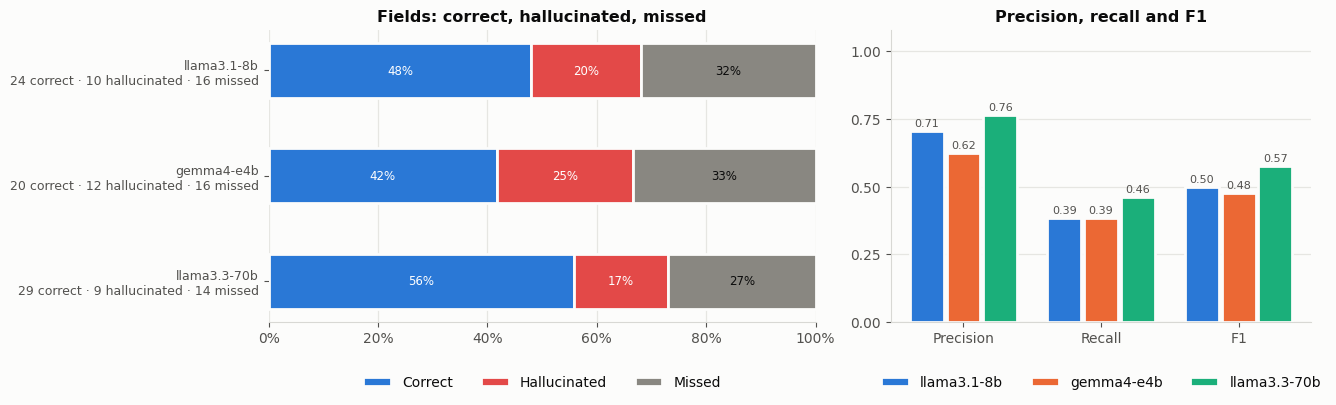

In [16]:
if not samples:
    print("skipped - no reference for this sample")
else:
    models = list(summary.index)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})

    # ── Shares, one bar per model ─────────────────────────────────────────────────
    labels = [f"{m}\n{int(summary.loc[m, 'correct'])} correct · {int(summary.loc[m, 'hallucinated'])} hallucinated · "
              f"{int(summary.loc[m, 'missed'])} missed" for m in models]
    left = [0.0] * len(models)
    for v in ("Correct", "Hallucinated", "Missed"):
        vals = [summary.loc[m, f"{v.lower()} %"] for m in models]
        bars = ax1.barh(labels, vals, left=left, height=0.52, color=VERDICT_COLOUR[v],
                        edgecolor=SURFACE, linewidth=2, label=v)
        for bar, val in zip(bars, vals):
            if val >= 0.05:                                       # percentage inside the segment when it fits
                ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2, f"{val:.0%}",
                         ha="center", va="center", fontsize=8.5, color="white" if v != "Missed" else INK)
        left = [l + x for l, x in zip(left, vals)]
    ax1.set_xlim(0, 1)
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax1.invert_yaxis()
    ax1.tick_params(axis="y", labelsize=9)
    ax1.set_title("Fields: correct, hallucinated, missed")
    ax1.grid(axis="x", color=GRID, linewidth=0.9)
    ax1.set_axisbelow(True)
    ax1.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    for side in ("top", "right", "left"):
        ax1.spines[side].set_visible(False)

    # ── Precision / recall / F1 per model ────────────────────────────────────────
    shown = ["precision", "recall", "f1"]
    w = 0.8 / len(models)
    for k, m in enumerate(models):
        xs = [i + (k - (len(models) - 1) / 2) * w for i in range(len(shown))]
        bars = ax2.bar(xs, [summary.loc[m, s] for s in shown], width=w * 0.92,
                       color=MODEL_COLOUR[m], edgecolor=SURFACE, linewidth=2, label=m)
        ax2.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color=MUTED)
    ax2.set_xticks(range(len(shown)))
    ax2.set_xticklabels(["Precision", "Recall", "F1"])
    ax2.set_ylim(0, 1.08)
    ax2.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax2.set_title("Precision, recall and F1")
    ax2.grid(axis="y", color=GRID, linewidth=0.9)
    ax2.set_axisbelow(True)
    ax2.legend(ncol=len(models), loc="upper center", bbox_to_anchor=(0.5, -0.14))
    for side in ("top", "right"):
        ax2.spines[side].set_visible(False)

    plt.tight_layout()
    fig.savefig(CHART, dpi=200, bbox_inches="tight", facecolor=SURFACE)
    plt.show()


## 9. Save

The results as an Excel workbook — a summary sheet and one sheet per model listing every
field and its mark — and the charts as an image, both in this run's folder.


In [17]:
if not samples:
    print("skipped - no reference for this sample")
else:
    with pd.ExcelWriter(RESULTS) as xw:
        summary.to_excel(xw, sheet_name="summary")
        for m in MODELS:
            d = details[details["model"] == m]
            if not d.empty:
                d.drop(columns="model").to_excel(xw, sheet_name=m[:31], index=False)
        details.to_excel(xw, sheet_name="details", index=False)
    print(f"saved -> {RESULTS}")
    print(f"saved -> {CHART}")


saved -> data\output\rda\runs\v9-narrative\evaluation_results.xlsx
saved -> data\output\rda\runs\v9-narrative\evaluation_charts.png


## In plain words

A short reading of the results, written from the numbers above so it is always current.


In [18]:
if not samples:
    print("skipped - no reference for this sample")
else:
    n_ref = int(summary["fields in reference"].iloc[0])
    print(f"The person filled in {n_ref} fields for sample {samples[0]}.\n")
    for m in summary.index:
        s = summary.loc[m]
        print(f"{m} wrote {int(s['fields output'])} fields: {int(s['correct'])} were right, "
              f"{int(s['hallucinated'])} were wrong or made up. It found {n_ref - int(s['missed'])} of the "
              f"{n_ref} fields in the document ({s['recall']:.0%}) and missed {int(s['missed'])}.")

    best_p, best_r, best_f = summary["precision"].idxmax(), summary["recall"].idxmax(), summary["f1"].idxmax()
    print()
    print(f"Most reliable: {best_p} - {summary.loc[best_p, 'precision']:.0%} of what it wrote was right.")
    print(f"Found the most: {best_r} - {summary.loc[best_r, 'recall']:.0%} of the document's fields.")
    print(f"Best overall (F1): {best_f}.")

    part = by_section.drop(columns="reference fields").sum(axis=1).idxmax()
    missed_here = by_section.loc[part].drop("reference fields")
    print(f"\nWhere it goes wrong: the '{part}' part of the form holds {int(by_section.loc[part, 'reference fields'])} "
          f"of the {n_ref} fields, and the models miss between {int(missed_here.min())} and {int(missed_here.max())} of them.")


The person filled in 26 fields for sample 3.

llama3.1-8b wrote 34 fields: 24 were right, 10 were wrong or made up. It found 10 of the 26 fields in the document (38%) and missed 16.
gemma4-e4b wrote 32 fields: 20 were right, 12 were wrong or made up. It found 10 of the 26 fields in the document (38%) and missed 16.
llama3.3-70b wrote 38 fields: 29 were right, 9 were wrong or made up. It found 12 of the 26 fields in the document (46%) and missed 14.

Most reliable: llama3.3-70b - 76% of what it wrote was right.
Found the most: llama3.3-70b - 46% of the document's fields.
Best overall (F1): llama3.3-70b.

Where it goes wrong: the 'dataset' part of the form holds 24 of the 26 fields, and the models miss between 13 and 15 of them.
